
FIRST 5 RECORDS

        Player  Matches  Batting Avg  Strike Rate  Bowling Economy  \
0  LMP Simmons        8        20.71       116.94             0.00   
1     RP Singh        4         0.00         0.00             8.45   
2    RG Sharma       50        26.16       134.81             0.00   
3     I Sharma       50        10.00        80.00             8.05   
4    HH Pandya       50        26.08       136.49             8.76   

   Bowling Avg Wickets  
0                 0.00  
1                 0.75  
2                 0.00  
3                 0.80  
4                 0.63  

DATASET INFO

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Player               486 non-null    object 
 1   Matches              486 non-null    int64  
 2   Batting Avg          486 non-null    float64
 3   Strike Rate          486 non-null    

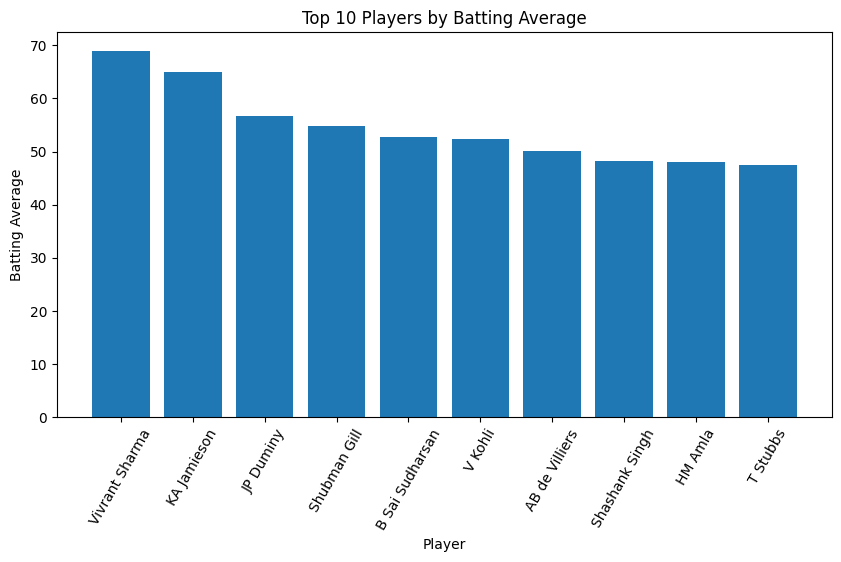

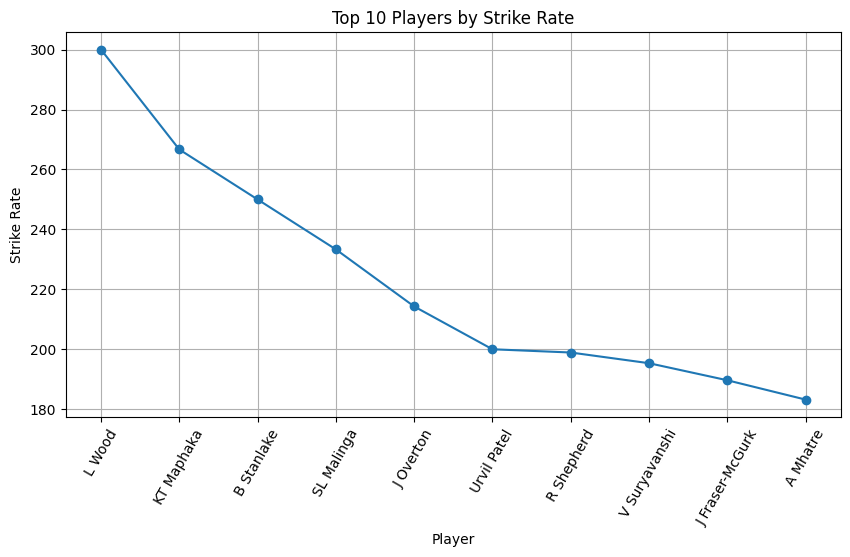

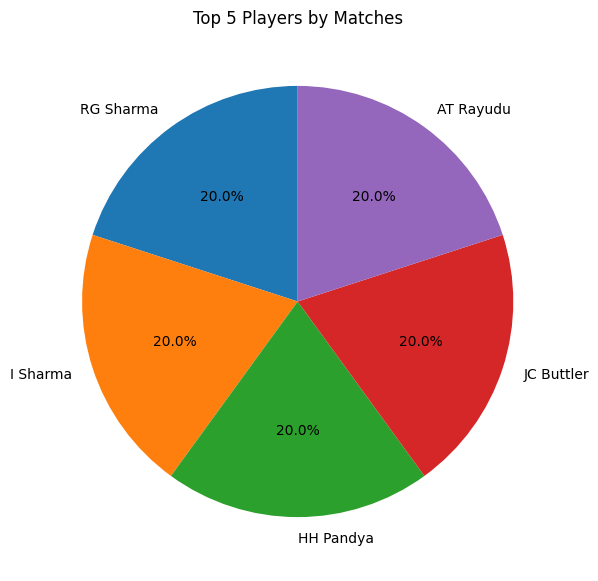

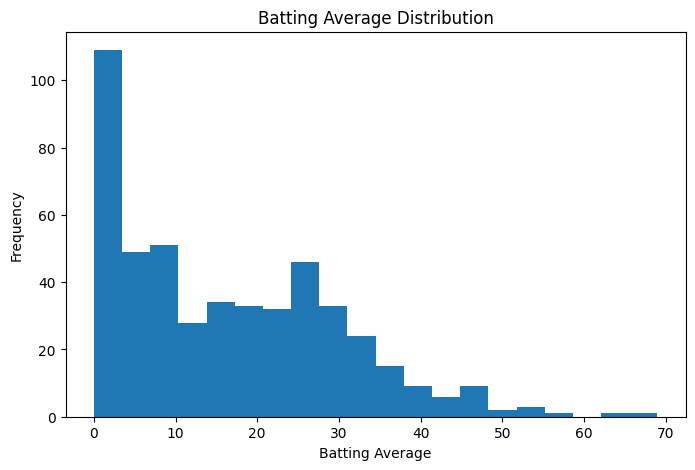

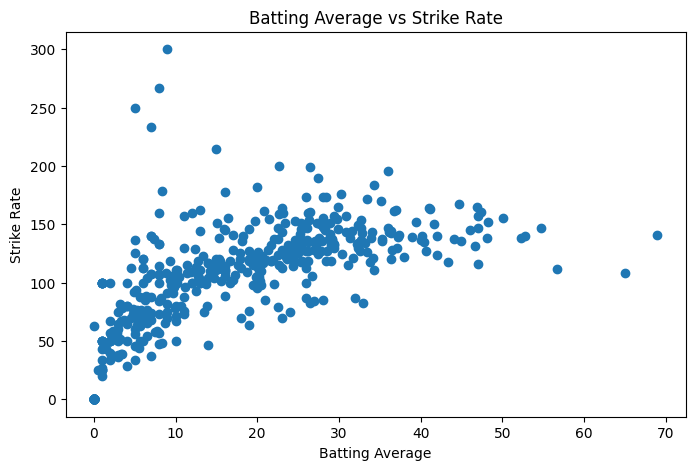

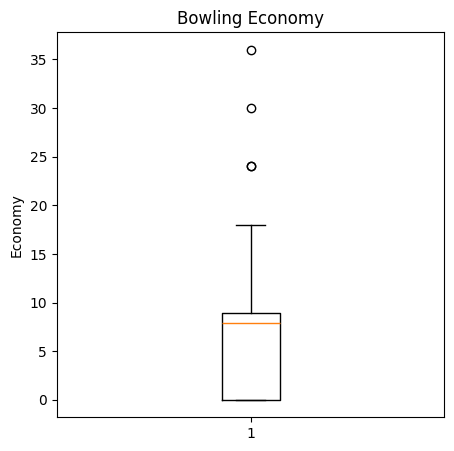

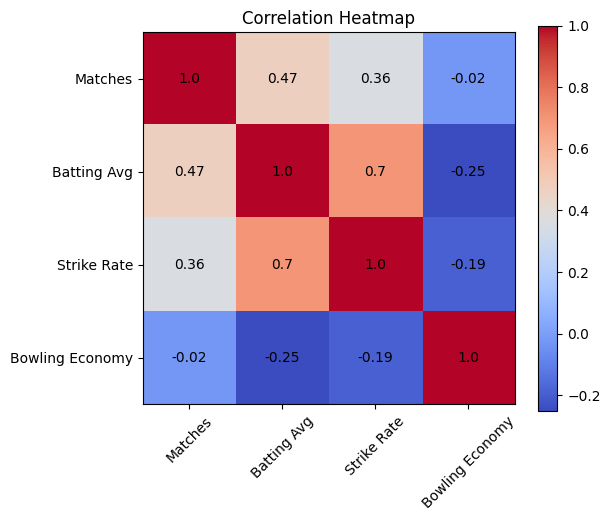

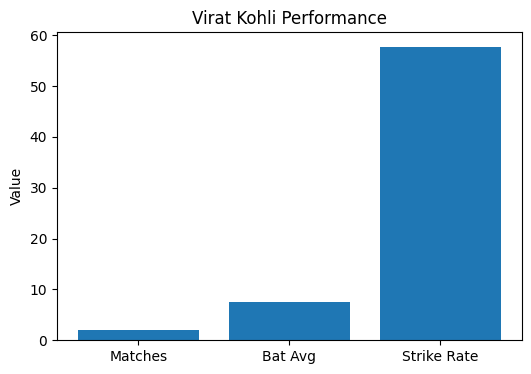


INTERESTING INSIGHTS

Highest Batting Average Player : Vivrant Sharma
Highest Strike Rate Player : L Wood
Most Matches Played : RG Sharma
Best Bowler (Lowest Economy) : LMP Simmons

Average Batting Average : 16.38
Average Strike Rate : 97.52
Average Bowling Economy : 6.34

Insight : Virat Kohli is one of the most consistent batsmen in IPL history with an excellent batting average and strike rate.


In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open("IPL_Stat_with_season_All_Player_who_played_in_2016_2025.json","r") as f:
    data=json.load(f)

players=[]

for player,details in data.items():
    recent=details.get("Last_recent_matches",{})

    players.append({
        "Player":player,
        "Matches":recent.get("M",0),
        "Batting Avg":recent.get("Bt_Avg",0),
        "Strike Rate":recent.get("Bt_Strike_rate",0),
        "Bowling Economy":recent.get("Bw_economy",0),
        "Bowling Avg Wickets":recent.get("Bw_Avg_Wickets",0)
    })

df=pd.DataFrame(players)

print("\nFIRST 5 RECORDS\n")
print(df.head())

print("\nDATASET INFO\n")
print(df.info())

print("\nSTATISTICAL SUMMARY\n")
print(df.describe())

print("\nMISSING VALUES\n")
print(df.isnull().sum())

print("\nDUPLICATE ROWS :",df.duplicated().sum())

print("\nDATASET SHAPE :",df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nTOP 10 BATTING AVERAGE")
print(df.nlargest(10,"Batting Avg")[["Player","Batting Avg"]])

print("\nTOP 10 STRIKE RATE")
print(df.nlargest(10,"Strike Rate")[["Player","Strike Rate"]])

print("\nTOP 10 MATCHES")
print(df.nlargest(10,"Matches")[["Player","Matches"]])

print("\nCORRELATION MATRIX")
corr=df[["Matches","Batting Avg","Strike Rate","Bowling Economy"]].corr()
print(corr)

df.to_csv("IPL_Processed_Data.csv",index=False)
df.nlargest(10,"Batting Avg").to_csv("Top10_Batsmen.csv",index=False)

top=df.nlargest(10,"Batting Avg")

plt.figure(figsize=(10,5))
plt.bar(top["Player"],top["Batting Avg"])
plt.title("Top 10 Players by Batting Average")
plt.xlabel("Player")
plt.ylabel("Batting Average")
plt.xticks(rotation=60)
plt.savefig("bar_chart.png")
plt.show()

top=df.nlargest(10,"Strike Rate")

plt.figure(figsize=(10,5))
plt.plot(top["Player"],top["Strike Rate"],marker='o')
plt.title("Top 10 Players by Strike Rate")
plt.xlabel("Player")
plt.ylabel("Strike Rate")
plt.xticks(rotation=60)
plt.grid()
plt.savefig("line_chart.png")
plt.show()

top=df.nlargest(5,"Matches")

plt.figure(figsize=(7,7))
plt.pie(top["Matches"],labels=top["Player"],autopct="%1.1f%%",startangle=90)
plt.title("Top 5 Players by Matches")
plt.savefig("pie_chart.png")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["Batting Avg"],bins=20)
plt.title("Batting Average Distribution")
plt.xlabel("Batting Average")
plt.ylabel("Frequency")
plt.savefig("histogram.png")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["Batting Avg"],df["Strike Rate"])
plt.title("Batting Average vs Strike Rate")
plt.xlabel("Batting Average")
plt.ylabel("Strike Rate")
plt.savefig("scatter_plot.png")
plt.show()

plt.figure(figsize=(5,5))
plt.boxplot(df["Bowling Economy"])
plt.title("Bowling Economy")
plt.ylabel("Economy")
plt.savefig("box_plot.png")
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(corr,cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j,i,round(corr.iloc[i,j],2),ha='center',va='center')

plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")
plt.show()

vk=df[df["Player"].str.contains("Virat",case=False)]

if not vk.empty:
    plt.figure(figsize=(6,4))
    plt.bar(["Matches","Bat Avg","Strike Rate"],
            [vk["Matches"].values[0],
             vk["Batting Avg"].values[0],
             vk["Strike Rate"].values[0]])
    plt.title("Virat Kohli Performance")
    plt.ylabel("Value")
    plt.savefig("virat_kohli_chart.png")
    plt.show()

print("\nINTERESTING INSIGHTS\n")

print("Highest Batting Average Player :",df.loc[df["Batting Avg"].idxmax(),"Player"])
print("Highest Strike Rate Player :",df.loc[df["Strike Rate"].idxmax(),"Player"])
print("Most Matches Played :",df.loc[df["Matches"].idxmax(),"Player"])
print("Best Bowler (Lowest Economy) :",df.loc[df["Bowling Economy"].idxmin(),"Player"])

print("\nAverage Batting Average :",round(df["Batting Avg"].mean(),2))
print("Average Strike Rate :",round(df["Strike Rate"].mean(),2))
print("Average Bowling Economy :",round(df["Bowling Economy"].mean(),2))

print("\nInsight : Virat Kohli is one of the most consistent batsmen in IPL history with an excellent batting average and strike rate.")